# Useful imports

In [1]:
from All_Functions_saddle import *
import sympy as sp
import numpy as np
import copy
import scipy.stats as scp
import math
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 30,           # Dimensione generale del font
    'axes.titlesize': 30,      # Titolo dell'asse
    'axes.labelsize': 30,      # Etichette degli assi
    'legend.fontsize': 30,     # Legenda
    'xtick.labelsize': 30,     # Etichette asse x
    'ytick.labelsize': 30      # Etichette asse y
})

plt.rcParams['text.latex.preamble']=r"\usepackage{lmodern}"
plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 30
plt.rcParams['font.family'] = 'lmodern'

# Plot of coefficients

In [ ]:
N_PC_values = [2,3,4]                   # Truncation degree of Polynomial Chaos expansion

a = sp.Rational(0,1)       # left extremum of the interval
b = sp.Rational(1,1)        # right extremum of the interval

for N_PC in N_PC_values:
    # Mean and standard deviation (note: sigma must be scaled by sqrt(3) and then squared to obtain the variance)
    N_sample_mu = 50
    h = sp.Rational(b - a, N_sample_mu)
    mu = np.arange(a, b + h, h)

    N_sample_sigma = 1
    sigma = [sp.Rational(1,5)]
    # N_sample_sigma = 10
    # sigma = [sp.Rational(i*sp.Rational(2,5),N_sample_sigma) for i in range(1,N_sample_sigma+1)]

    solutions = multiple_systems_solver(mu, sigma, N_PC)

    Plot_of_coefficients(N_PC, mu, sigma, solutions)

In [ ]:
def collect_coefficients(mu, solutions, N):
    """Extracts mu values and coefficients for given N"""
    mu_values = []
    C = [[] for _ in range(N + 1)]

    for i in range(len(mu)):
        if solutions[i] != []:
            for j in range(len(solutions[i])):
                mu_values.append(mu[i])
                for k in range(N + 1):
                    C[k].append(solutions[i][j][k])
    return mu_values, C

def Plot_grouped_coefficients(all_data):
    """Plots coefficients grouped by c_k with different N_PC curves in each plot"""
    max_N = max(all_data.keys())
    markers = ["o","^","x"]
    for k in range(max_N + 1):
        fig, ax = plt.subplots(figsize=(10.5, 5))

        for N_PC, (mu_values, C) in all_data.items():
            if k <= N_PC:  # Only plot if this coefficient exists for current N_PC
                ax.scatter(mu_values, C[k], marker=markers[N_PC-2], label=rf"$N={N_PC}$", color=plt.cm.tab10(N_PC % 10), alpha=0.7)

        ax.set_xlabel(r"$\mu$")
        ax.set_ylabel(rf"$c_{k}$")
        ax.grid(True)
        ax.set_xlim([0, 1])
        ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.05), ncol=2)

        fig.savefig(f"Plots/Grouped_Plot_c_{k}.pdf", bbox_inches='tight')

N_PC_values = [2, 3, 4]  # Truncation degrees
a = sp.Rational(0, 1)
b = sp.Rational(1, 1)
N_sample_mu = 50
h = sp.Rational(b - a, N_sample_mu)
mu = [sp.Rational(a + i * h) for i in range(N_sample_mu + 1)]

sigma = [sp.Rational(1, 5)]

# Dictionary to collect all data for each N_PC
all_data = {}

for N_PC in N_PC_values:
    solutions = multiple_systems_solver(mu, sigma, N_PC)
    mu_vals, coeffs = collect_coefficients(mu, solutions, N_PC)
    all_data[N_PC] = (mu_vals, coeffs)

# Plot all coefficients grouped by c_k
Plot_grouped_coefficients(all_data)

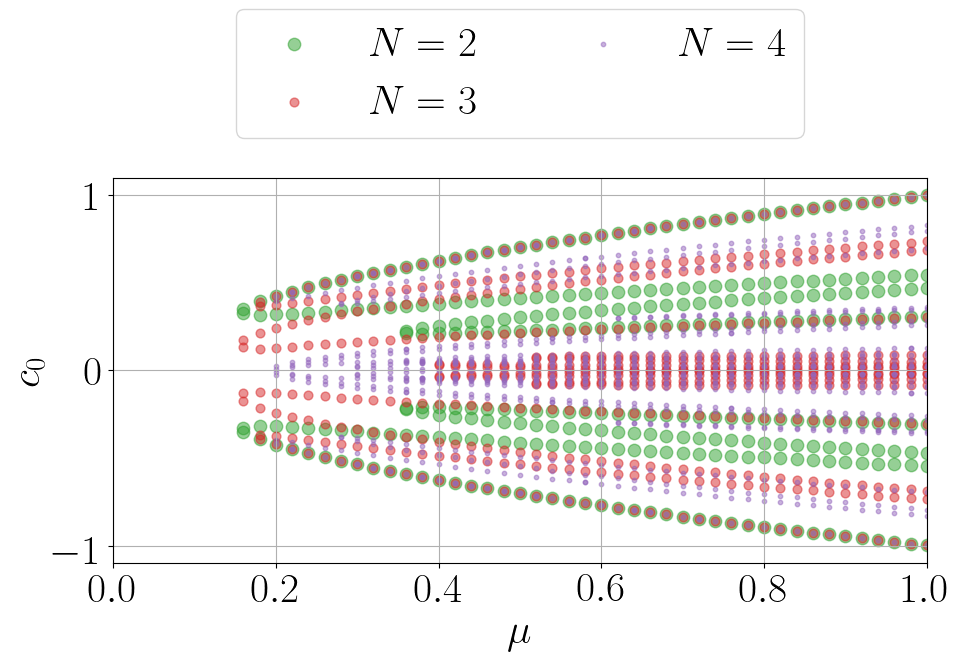

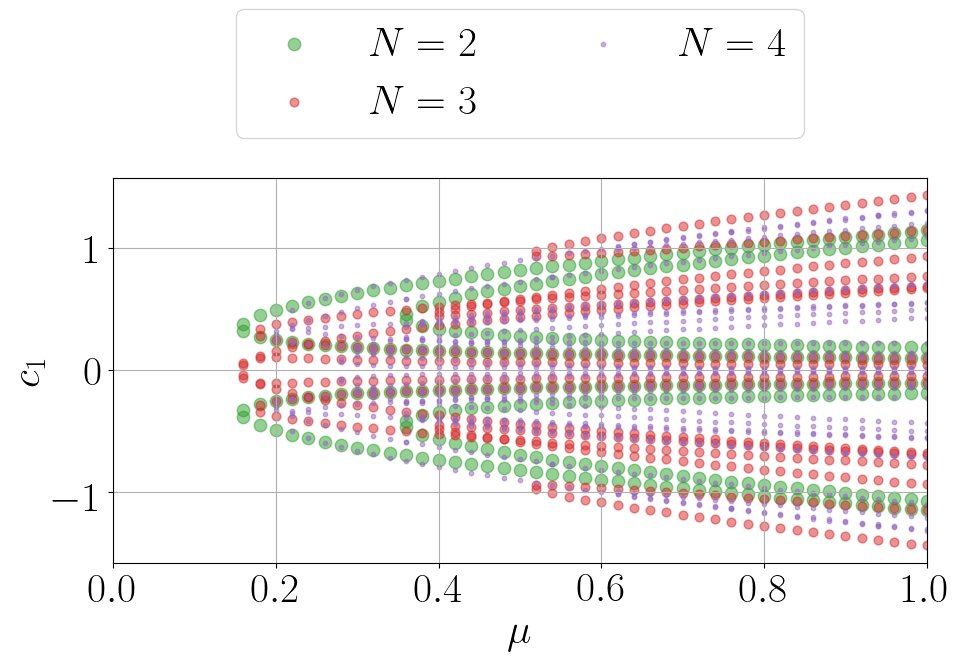

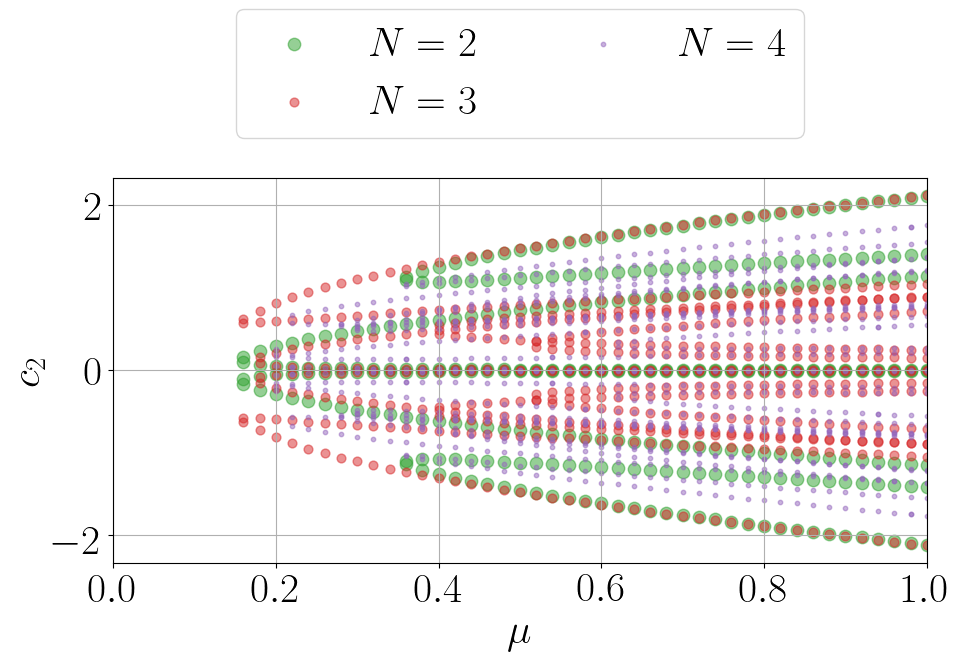

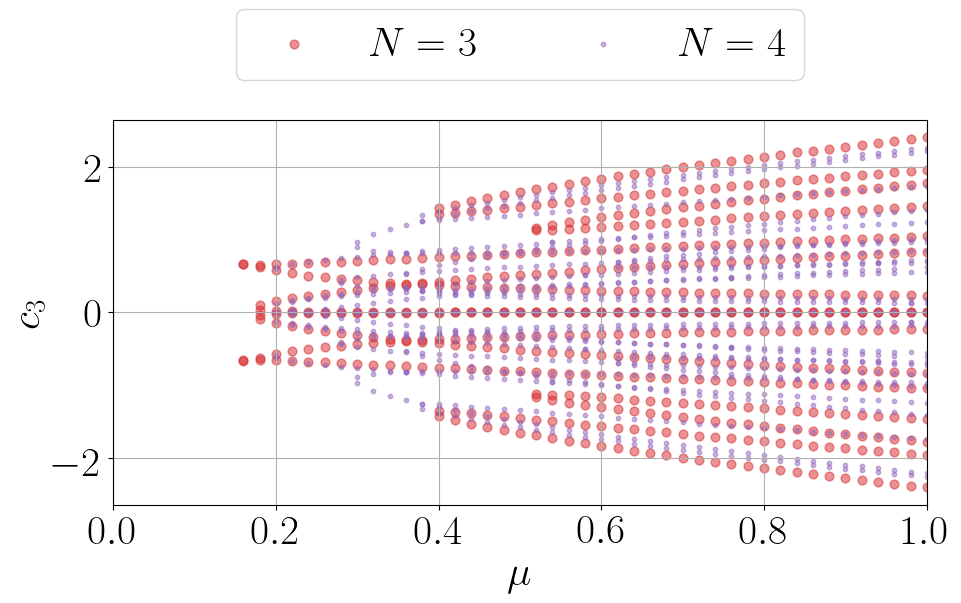

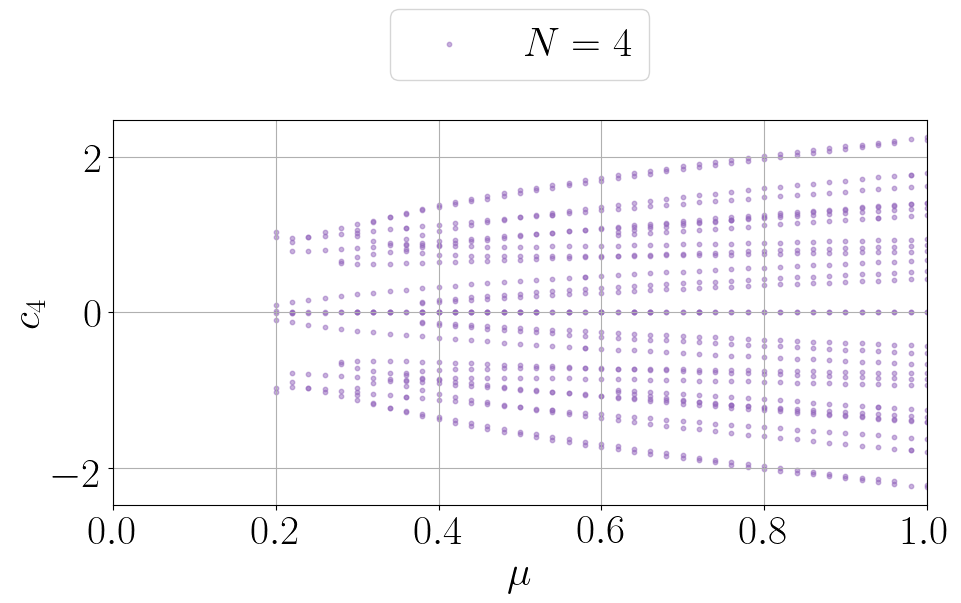

In [2]:
def collect_coefficients(mu, solutions, N):
    """Extracts mu values and coefficients for given N"""
    mu_values = []
    C = [[] for _ in range(N + 1)]

    for i in range(len(mu)):
        if solutions[i] != []:
            for j in range(len(solutions[i])):
                mu_values.append(mu[i])
                for k in range(N + 1):
                    C[k].append(solutions[i][j][k])
    return mu_values, C

def Plot_grouped_coefficients(all_data):
    """Plots coefficients grouped by c_k with different N_PC curves in each plot,
    using larger dots for lower order N_PC values"""
    import matplotlib.pyplot as plt

    max_N = max(all_data.keys())
    markers = ["o", "o", "o"]
    sizes = {2: 80, 3: 40, 4: 10}  # Customize sizes: large for N=2 & 4, medium for N=3

    for k in range(max_N + 1):
        fig, ax = plt.subplots(figsize=(10.5, 5))

        for N_PC, (mu_values, C) in all_data.items():
            if k <= N_PC:
                ax.scatter(mu_values, C[k], marker=markers[N_PC - 2], s=sizes.get(N_PC, 50), label=rf"$N={N_PC}$", color=plt.cm.tab10(N_PC % 10), alpha=0.5)

        ax.set_xlabel(r"$\mu$")
        ax.set_ylabel(rf"$c_{k}$")
        ax.grid(True)
        ax.set_xlim([0, 1])
        ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.05), ncol=2)

        fig.savefig(f"Plots/Grouped_Plot_c_{k}.pdf", bbox_inches='tight')

N_PC_values = [2, 3, 4]  # Truncation degrees
a = sp.Rational(0, 1)
b = sp.Rational(1, 1)
N_sample_mu = 50
h = sp.Rational(b - a, N_sample_mu)
mu = [sp.Rational(a + i * h) for i in range(N_sample_mu + 1)]

sigma = [sp.Rational(1, 5)]

# Dictionary to collect all data for each N_PC
all_data = {}

for N_PC in N_PC_values:
    solutions = multiple_systems_solver(mu, sigma, N_PC)
    mu_vals, coeffs = collect_coefficients(mu, solutions, N_PC)
    all_data[N_PC] = (mu_vals, coeffs)

# Plot all coefficients grouped by c_k
Plot_grouped_coefficients(all_data)

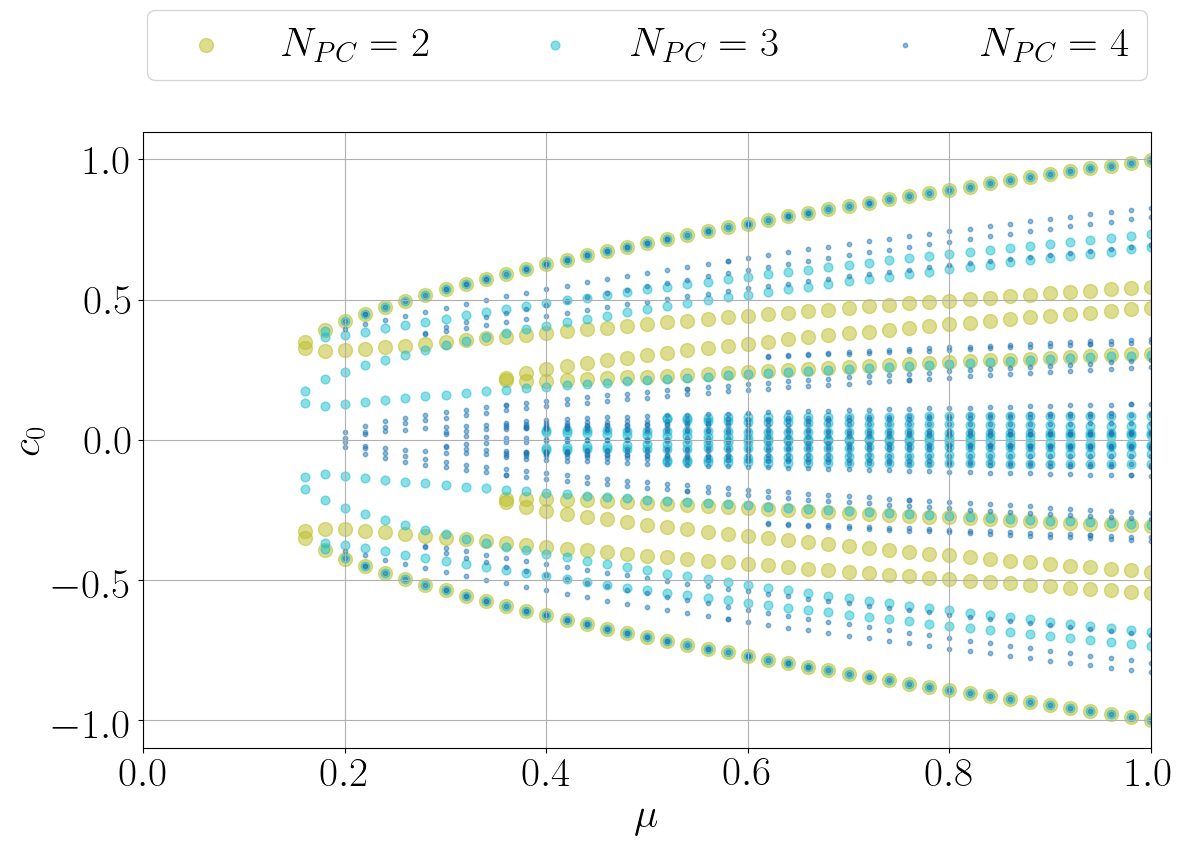

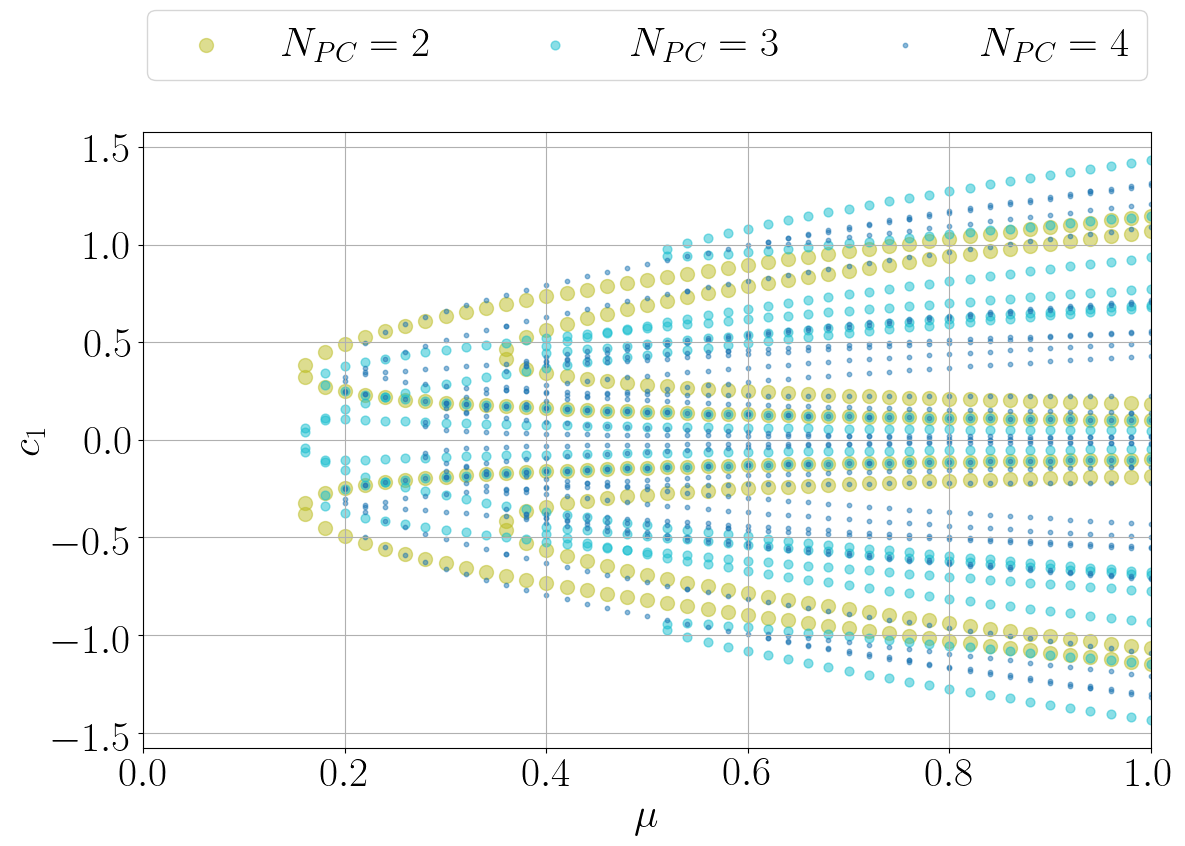

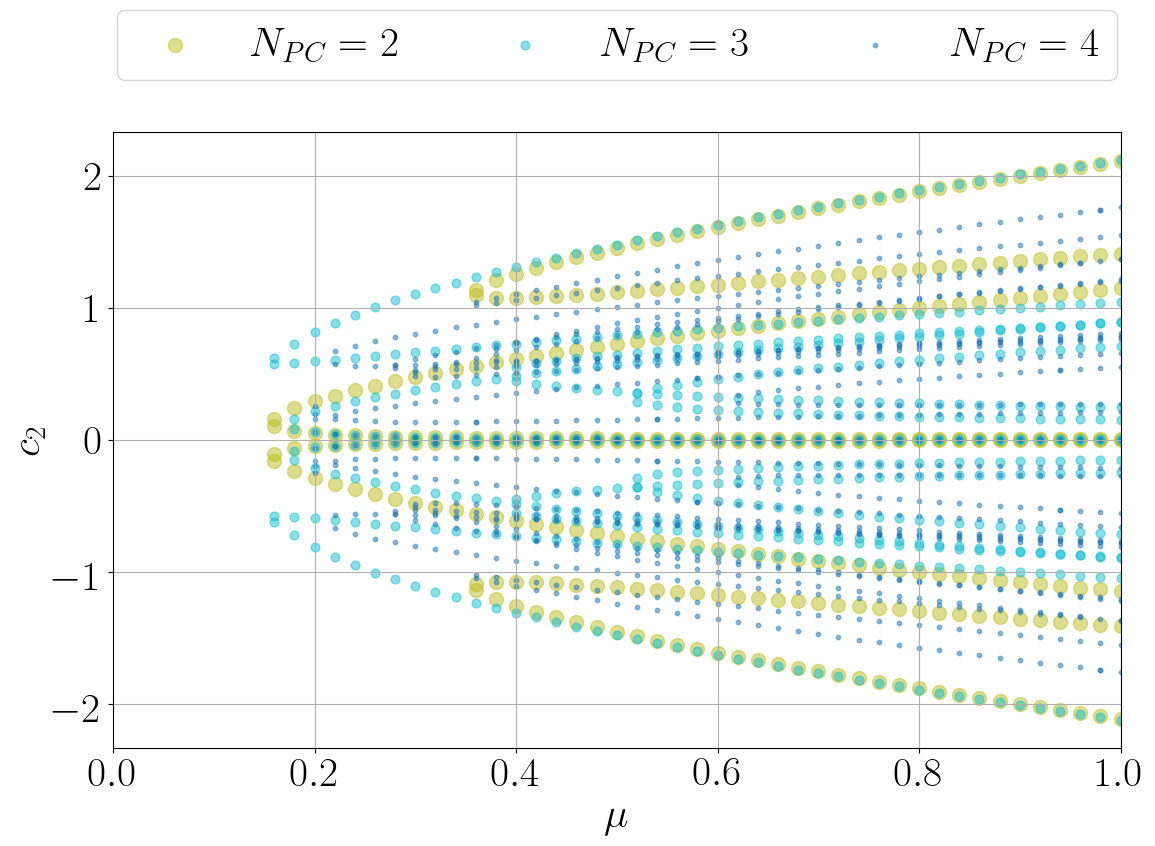

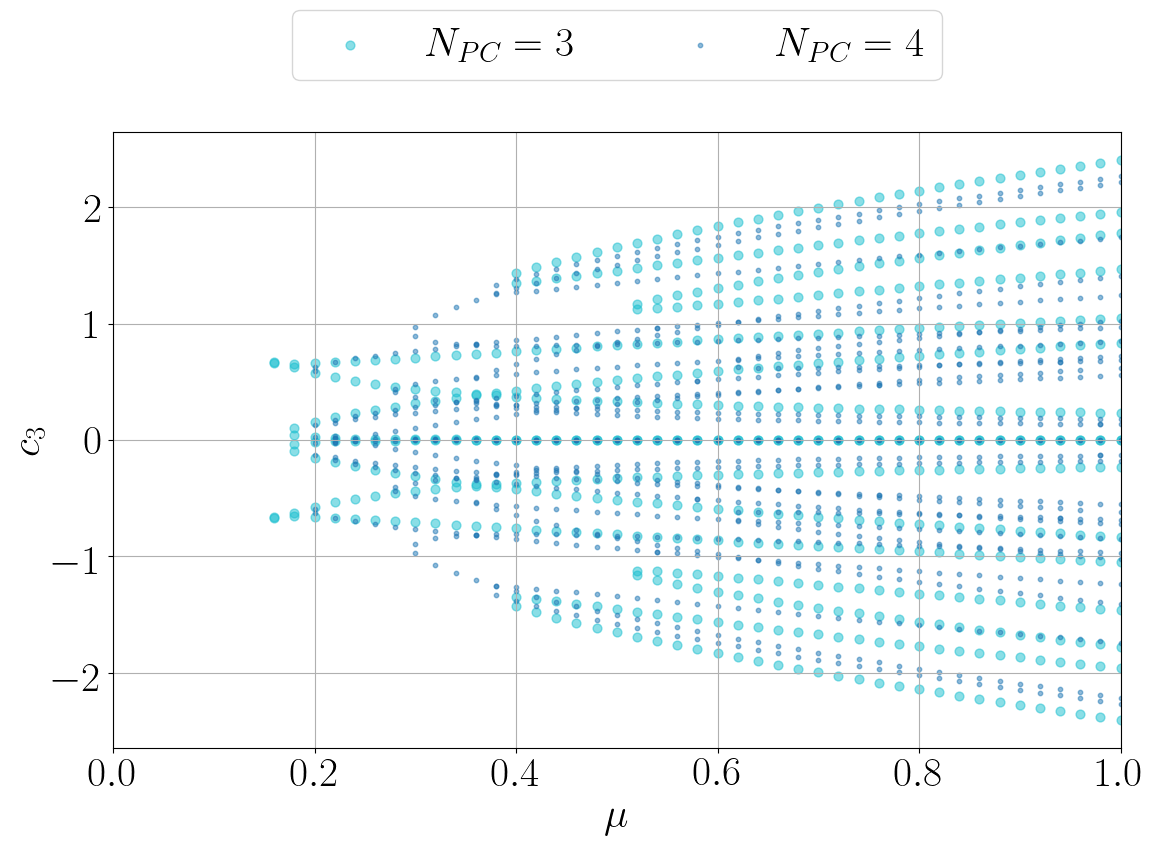

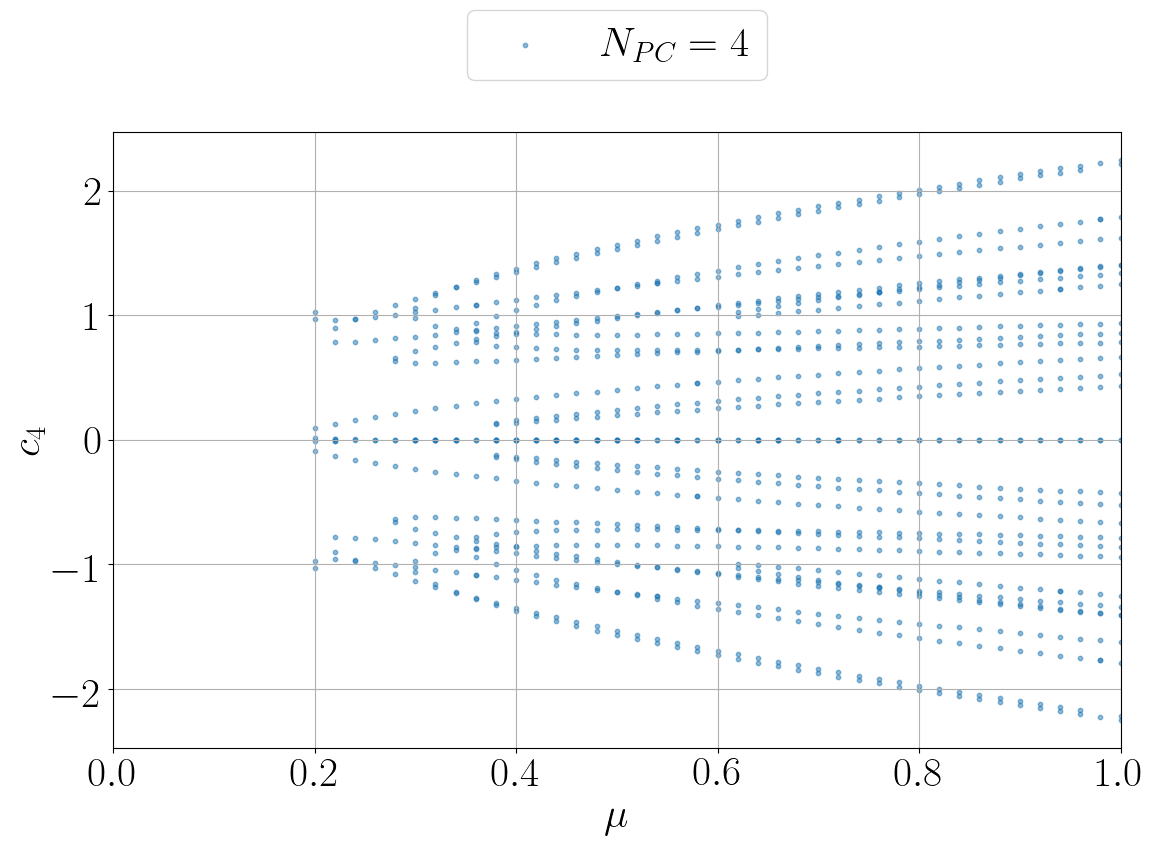

In [8]:
def Plot_grouped_coefficients(all_data):
    """Plots coefficients grouped by c_k with different N_PC curves in each plot,
    using larger dots for lower order N_PC values"""
    import matplotlib.pyplot as plt

    max_N = max(all_data.keys())
    markers = ["o", "o", "."]
    sizes = {2: 100, 3: 40, 4: 40}  # Customize sizes: large for N=2 & 4, medium for N=3

    for k in range(max_N + 1):
        fig, ax = plt.subplots(figsize=(13, 8))

        for N_PC, (mu_values, C) in all_data.items():
            if k <= N_PC:
                ax.scatter(mu_values, C[k], marker=markers[N_PC - 2], s=sizes.get(N_PC, 50), label=rf"$N_{{PC}}={N_PC}$", color=plt.cm.tab10((N_PC+6) % 10), alpha=0.5)

        ax.set_xlabel(r"$\mu$")
        ax.set_ylabel(rf"$c_{k}$")
        ax.grid(True)
        ax.set_xlim([0, 1])
        ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.05), ncol=3)

        fig.savefig(f"Plots/Grouped_Plot_c_{k}.pdf", bbox_inches='tight')

Plot_grouped_coefficients(all_data)

# Plot of final polynomials, given $N_{PC}$, $\sigma$, $\mu$

In [ ]:
N_PC = 3

mu = sp.Rational(1, 2)

s = sp.Rational(4, 5)

solutions = []

# Build the necessary matrices and system
matrices, F, Variables = Build_matrices(N_PC)

G = Build_system(F, mu, s)

# Solve the system and extract the real-valued solutions
ordered_solutions, solutions_vector = System_solver(G, Variables, N_PC)
number_real_solutions, real_solutions_vector = count_real_solutions(solutions_vector)
updated_solutions, residuals = Numerical_solutions(Variables, G, real_solutions_vector)

# Output information about the setup and number of real solutions found
print(f"mu = {mu}, sigma = {s * math.sqrt(3)} \nNumber of real solutions: {number_real_solutions}")

# Generate and validate the set of accepted polynomials
polynomials = Calculate_polynomials_optimized(N_PC, mu, s, updated_solutions, residuals)
number_accepted_polynomials = len(polynomials)
print(f"Accepted polynomials: {number_accepted_polynomials}")
print("-" * 50)

# Plot the resulting polynomials
Plot_polynomials_optimized(polynomials, mu, s)

# Statistics

In [ ]:
number_of_sampling = 101
sampling_grid = np.linspace(mu-s, mu+s, number_of_sampling)

polynomial_values = []
y = sp.symbols("y")

for pol in polynomials:
    for j in range(0, number_of_sampling):
        polynomial_values.append(float(pol.subs(y, sampling_grid[j])))

# Determine plot range based on data
x_max = 2*max(polynomial_values)
x_min = -x_max
subdivision_number = int(x_max*10)
h = 2*x_max/subdivision_number
x_range = np.arange(x_min, x_max + float(h), float(h))
# Create a new plot for histogram and KDE with confidence bands
fig, ax = plt.subplots(1, 1, figsize=(10.5, 5))

# Plot normalized histogram
ax.hist(polynomial_values, bins=x_range, density=True, alpha=0.5, label='PDF (Histogram)')
ax.axvline(math.sqrt(mu), color='g', linestyle='dotted', linewidth=2, label="Expected mean value")
ax.axvline(-math.sqrt(mu), color='g', linestyle='dotted', linewidth=2,)
ax.set_xlabel("Values")
ax.set_ylabel("Density")
ax.legend()
plt.show()

### KDE and bootstrap

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10.5, 5))

ax.hist(polynomial_values, bins=x_range, density=True, alpha=0.5, label='PDF (Histogram)')
ax.axvline(math.sqrt(mu), color='g', linestyle='dotted', linewidth=2, label="Expected mean value")
ax.axvline(-math.sqrt(mu), color='g', linestyle='dotted', linewidth=2,)

# Compute Kernel Density Estimate (KDE)
kde = scp.gaussian_kde(polynomial_values)
x_kde = np.linspace(x_min, x_max, 1000)
kde_values = kde(x_kde)

# Bootstrap KDE estimates to generate a 95% confidence band
n_bootstraps = 100
bootstrap_kdes = []

for _ in range(n_bootstraps):
    sample = np.random.choice(polynomial_values, size=len(polynomial_values), replace=True)
    kde_sample = scp.gaussian_kde(sample)
    bootstrap_kdes.append(kde_sample(x_kde))

bootstrap_kdes = np.array(bootstrap_kdes)
lower = np.percentile(bootstrap_kdes, 2.5, axis=0)
upper = np.percentile(bootstrap_kdes, 97.5, axis=0)

# Plot KDE and fill in the confidence interval
ax.plot(x_kde, kde_values, color='red', label='PDF (KDE)')
ax.fill_between(x_kde, lower, upper, color="red", alpha=0.2, label="95% Confidence Interval")

# Set labels, legend, and grid
ax.set_xlabel("Values")
ax.set_ylabel("Density")
ax.legend()
ax.grid(True)

# Display the final plot
plt.show()

## Stationary points Statistics

In [ ]:
# Compute critical points and evaluate polynomial values at those points
x_val, y_val = find_extrema(polynomials, mu, s)
y_val = np.array([float(y) for y in y_val])  # Convert to float for plotting
with open("output.txt", "w") as file:
    file.write(f"{y_val}")

# Scatter plot of critical values
fig, ax = plt.subplots(1, 1, figsize=(10.5, 5))
ax.scatter(x_val, y_val)
ax.grid(True)

# Determine plot range based on data
x_max = 2 * max(y_val)
x_min = -x_max
subdivision_number = int(x_max*10)
h = 2*x_max/subdivision_number
x_range = np.arange(x_min, x_max + float(h), float(h))
# Create a new plot for histogram and KDE with confidence bands
fig, ax = plt.subplots(1, 1, figsize=(10.5, 5))

# Plot normalized histogram
ax.hist(y_val, bins=x_range, density=True, alpha=0.5, label='PDF (Histogram)')
ax.axvline(math.sqrt(mu), color='g', linestyle='dotted', linewidth=2, label="Expected mean value")
ax.axvline(-math.sqrt(mu), color='g', linestyle='dotted', linewidth=2,)
ax.set_xlabel("Values")
ax.set_ylabel("Density")
ax.legend()
plt.show()

### KDE and bootstrap

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10.5, 5))

ax.hist(y_val, bins=x_range, density=True, alpha=0.5, label='PDF (Histogram)')
ax.axvline(math.sqrt(mu), color='g', linestyle='dotted', linewidth=2, label="Expected mean value")
ax.axvline(-math.sqrt(mu), color='g', linestyle='dotted', linewidth=2,)

# Compute Kernel Density Estimate (KDE)
kde = scp.gaussian_kde(y_val)
x_kde = np.linspace(x_min, x_max, 1000)
kde_values = kde(x_kde)

# Bootstrap KDE estimates to generate a 95% confidence band
n_bootstraps = 100
bootstrap_kdes = []

for _ in range(n_bootstraps):
    sample = np.random.choice(y_val, size=len(y_val), replace=True)
    kde_sample = scp.gaussian_kde(sample)
    bootstrap_kdes.append(kde_sample(x_kde))

bootstrap_kdes = np.array(bootstrap_kdes)
lower = np.percentile(bootstrap_kdes, 2.5, axis=0)
upper = np.percentile(bootstrap_kdes, 97.5, axis=0)

# Plot KDE and fill in the confidence interval
ax.plot(x_kde, kde_values, color='red', label='PDF (KDE)')
ax.fill_between(x_kde, lower, upper, color="red", alpha=0.2, label="95% Confidence Interval")

# Set labels, legend, and grid
ax.set_xlabel("Values")
ax.set_ylabel("Density")
ax.legend()
ax.grid(True)

# Display the final plot
plt.show()

# Number of solutions varying $\sigma$ 

In [ ]:
N_PC = 4

N_sample_sigma = 40
mu = sp.Rational(1,1)

solutions = []

matrices, F, Variables = Build_matrices(N_PC)

accepted_polynomials = []
sigma_values = []

for j in range(1, N_sample_sigma+1):
    sigma = sp.Rational(4*j,5*N_sample_sigma)
    sigma_values.append(sigma)
    H = copy.deepcopy(F) 
    G = Build_system(H, mu, sigma)

    ordered_solutions, solutions_vector = System_solver(G, Variables, N_PC)
    number_real_solutions, real_solutions_vector = count_real_solutions(solutions_vector)
    updated_solutions, residuals = Numerical_solutions(Variables, G, real_solutions_vector)
    polynomials = Calculate_polynomials(N_PC, mu, sigma, updated_solutions, residuals)
    #print(f"mu = {mu}, sigma = {sigma*math.sqrt(3)} \nNumber of real solutions: {number_real_solutions}")
    polynomials = Calculate_polynomials(N_PC, mu, sigma, updated_solutions, residuals)
    number_accepted_polynomials = len(polynomials)
    accepted_polynomials.append(number_accepted_polynomials)

plt.plot(sigma_values,accepted_polynomials)
plt.show()


# Plot of the extremas for different $\mu$ values 

In [ ]:
N_PC = 4
N_sample_mu = 45

a = sp.Rational(-1,2)       # lower bound of the interval
b = sp.Rational(1,1)        # upper bound of the interval
h = sp.Rational(b - a, N_sample_mu)

mu = np.arange(a, b + h, h)

N_sample_sigma = 1
sigma = [sp.Rational(1,100)]

mu_values = []
branch_values = []

matrices, F, Variables = Build_matrices(N_PC)

for i in range(0, N_sample_mu + 1):
    for j in range(0, N_sample_sigma):
        
        H = copy.deepcopy(F) 
        G = Build_system(H, mu[i], sigma[j])
        
        ordered_solutions, solutions_vector = System_solver(G, Variables, N_PC)
        number_real_solutions, real_solutions_vector = count_real_solutions(solutions_vector)
        updated_solutions, residuals = Numerical_solutions(Variables, G, real_solutions_vector)

        polynomials = Calculate_polynomials(N_PC, mu[i], sigma[j], updated_solutions, residuals)

        x_val, y_val = find_extrema(polynomials, mu[i], sigma[j])
        mu_val = [mu[i] for j in range (len(y_val))]
        mu_values.append(mu_val)
        branch_values.append(y_val)

mu_values = [float(item) for sublist in mu_values for item in sublist]
branch_values = [float(item) for sublist in branch_values for item in sublist]

# Construction of the grid
mu_bins = np.linspace(float(a), float(b), 100)
mu_bins_pos = np.linspace(max(float(a),0), float(b), 100)
y_bins = np.linspace(min(branch_values), max(branch_values), 200)

H, xedges, yedges = np.histogram2d(mu_values, branch_values, bins=[mu_bins, y_bins])

# Transposition, necessary for imshow
H = H.T
branches = np.sqrt(mu_bins_pos)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Show H
im = ax.imshow(H, aspect='auto', origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], cmap='Blues')

# True Branch
ax.plot(mu_bins_pos, branches, color="red", linestyle="--", label="Solution branches")
ax.plot(mu_bins_pos, -branches, color="red", linestyle="--")

ax.set_xlabel('mu')
ax.set_ylabel('Values')
ax.legend()
fig.colorbar(im, ax=ax, label='Density')
plt.show()
fig.savefig(f"Plots/Bifurcation_N_PC={N_PC}_mu_samples={N_sample_mu}_sigma={float(sigma[0])}.png")